In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../sigma_cabs.csv')

In [4]:
df.sample(5)

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type
39469,T0005755081,48.22,B,9.0,2.64813,A,B,1.08625,0,35.0,48,61,Male,2
26754,T0005733932,22.94,D,8.0,2.59920,B,B,4.22000,1,NaN,49,72,Male,3
94147,T0005846189,45.14,E,2.0,2.93269,B,K,2.35875,0,NaN,46,62,Male,3
63586,T0005795304,53.35,NaN,9.0,2.62679,C,D,1.90250,2,46.0,48,74,Female,3
90801,T0005840649,28.59,A,10.0,NaN,NaN,A,4.00250,0,37.0,51,67,Male,1


In [5]:
df.drop(columns = ['Trip_ID'],inplace = True)

In [6]:
df.sample(5)

,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type
100887,107.18,NaN,8.0,NaN,NaN,A,0.45875,0,NaN,52,73,Male,2
85910,13.49,B,8.0,2.48524,B,A,4.26875,0,66.0,46,68,Female,2
96132,32.28,B,10.0,2.59113,A,A,3.14625,0,NaN,49,67,Female,2
70616,60.16,A,10.0,2.93113,C,A,3.17875,2,33.0,66,108,Male,3
105501,36.34,B,10.0,NaN,NaN,A,3.85625,0,NaN,47,74,Female,2


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131662 entries, 0 to 131661
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Trip_Distance                131662 non-null  float64
 1   Type_of_Cab                  111452 non-null  object 
 2   Customer_Since_Months        125742 non-null  float64
 3   Life_Style_Index             111469 non-null  float64
 4   Confidence_Life_Style_Index  111469 non-null  object 
 5   Destination_Type             131662 non-null  object 
 6   Customer_Rating              131662 non-null  float64
 7   Cancellation_Last_1Month     131662 non-null  int64  
 8   Var1                         60632 non-null   float64
 9   Var2                         131662 non-null  int64  
 10  Var3                         131662 non-null  int64  
 11  Gender                       131662 non-null  object 
 12  Surge_Pricing_Type           131662 non-null  int64  
dtyp

In [8]:
df.describe(include = 'all')

,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type
count,131662.000000,111452,125742.000000,111469.000000,111469,131662,131662.000000,131662.000000,60632.000000,131662.000000,131662.000000,131662,131662.000000
unique,NaN,5,NaN,NaN,3,14,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,B,NaN,NaN,B,A,NaN,NaN,NaN,NaN,NaN,Male,NaN
freq,NaN,31136,NaN,NaN,40355,77597,NaN,NaN,NaN,NaN,NaN,93900,NaN
mean,44.200909,NaN,6.016661,2.802064,NaN,NaN,2.849458,0.782838,64.202698,51.202800,75.099019,NaN,2.155747
std,25.522882,NaN,3.626887,0.225796,NaN,NaN,0.980675,1.037559,21.820447,4.986142,11.578278,NaN,0.738164
min,0.310000,NaN,0.000000,1.596380,NaN,NaN,0.001250,0.000000,30.000000,40.000000,52.000000,NaN,1.000000
25%,24.580000,NaN,3.000000,2.654730,NaN,NaN,2.152500,0.000000,46.000000,48.000000,67.000000,NaN,2.000000
50%,38.200000,NaN,6.000000,2.798050,NaN,NaN,2.895000,0.000000,61.000000,50.000000,74.000000,NaN,2.000000
75%,60.730000,NaN,10.000000,2.946780,NaN,NaN,3.582500,1.000000,80.000000,54.000000,82.000000,NaN,3.000000


In [9]:
df.shape

(131662, 13)

In [10]:
df.isnull().sum()/len(df)*100

Trip_Distance                   0.000000
Type_of_Cab                    15.349911
Customer_Since_Months           4.496362
Life_Style_Index               15.336999
Confidence_Life_Style_Index    15.336999
Destination_Type                0.000000
Customer_Rating                 0.000000
Cancellation_Last_1Month        0.000000
Var1                           53.948748
Var2                            0.000000
Var3                            0.000000
Gender                          0.000000
Surge_Pricing_Type              0.000000
dtype: float64

In [11]:
df.dtypes

Trip_Distance                  float64
Type_of_Cab                     object
Customer_Since_Months          float64
Life_Style_Index               float64
Confidence_Life_Style_Index     object
Destination_Type                object
Customer_Rating                float64
Cancellation_Last_1Month         int64
Var1                           float64
Var2                             int64
Var3                             int64
Gender                          object
Surge_Pricing_Type               int64
dtype: object

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
num_cols_list = df.columns[df.dtypes != 'object']
numerical_columns = df[num_cols_list]

In [14]:
numerical_columns

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type
0,6.77,1.0,2.42769,3.90500,0,40.0,46,60,2
1,29.47,10.0,2.78245,3.45000,0,38.0,56,78,2
2,41.58,10.0,NaN,3.50125,2,NaN,56,77,2
3,61.56,10.0,NaN,3.45375,0,NaN,52,74,3
4,54.95,10.0,3.03453,3.40250,4,51.0,49,102,2
...,...,...,...,...,...,...,...,...,...
131657,11.72,1.0,2.74229,3.28500,0,61.0,47,76,3
131658,74.81,7.0,2.81059,0.44500,0,NaN,63,88,2
131659,40.17,10.0,2.99565,3.33625,0,NaN,48,75,2
131660,46.88,4.0,3.04744,4.15750,1,47.0,54,79,2


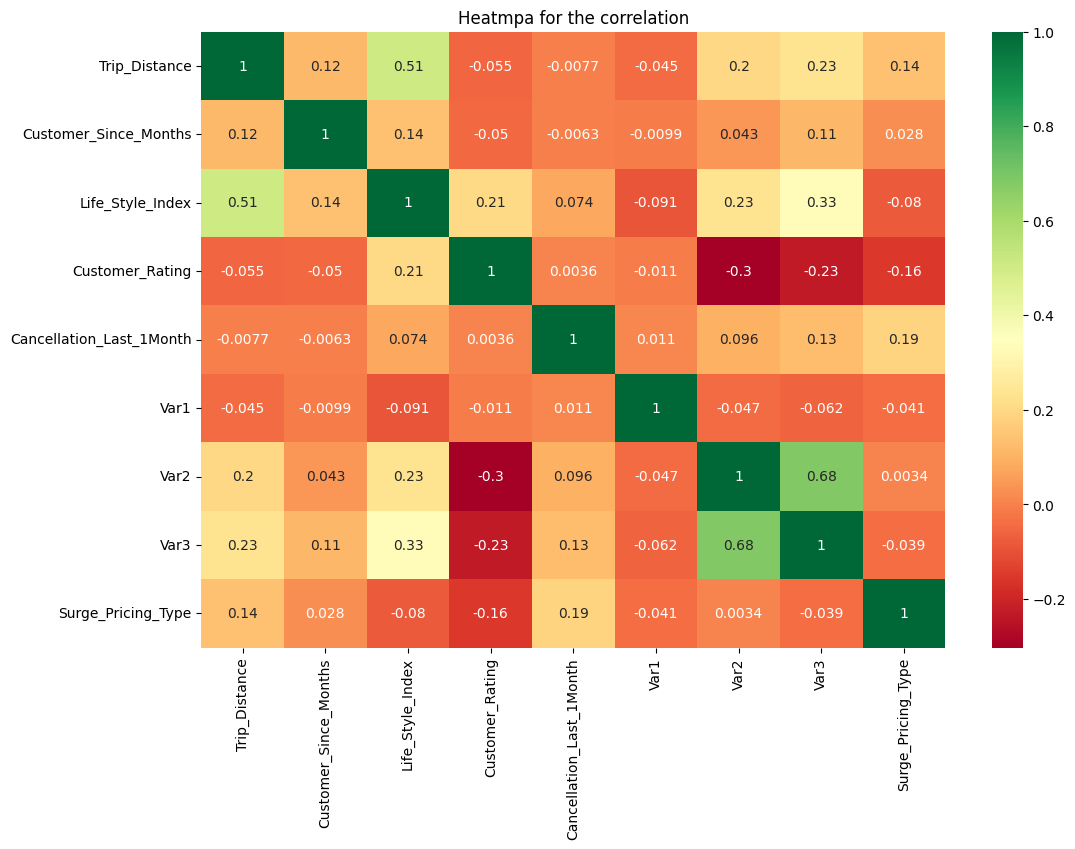

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(numerical_columns.corr(), annot=True, cmap='RdYlGn')
plt.title('Heatmpa for the correlation')

plt.show()

Text(0.5, 1.0, 'Surge Pricing Distribution by Cab Type')

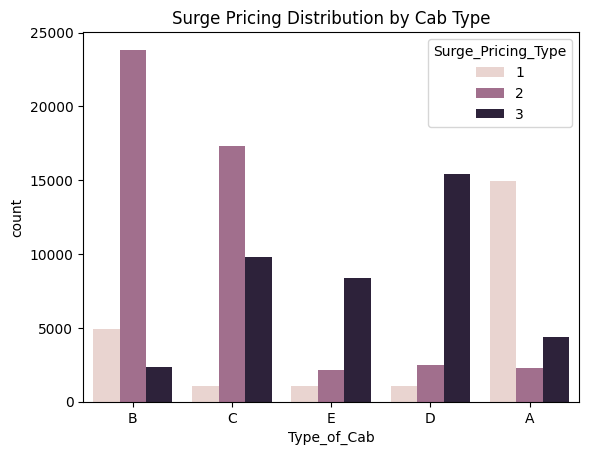

In [16]:
# See how Surge Pricing Type changes based on Cab Type
sns.countplot(data=df, x='Type_of_Cab', hue='Surge_Pricing_Type')
plt.title('Surge Pricing Distribution by Cab Type')

Text(0.5, 1.0, 'Surge Pricing Distribution by Life_Style_Index')

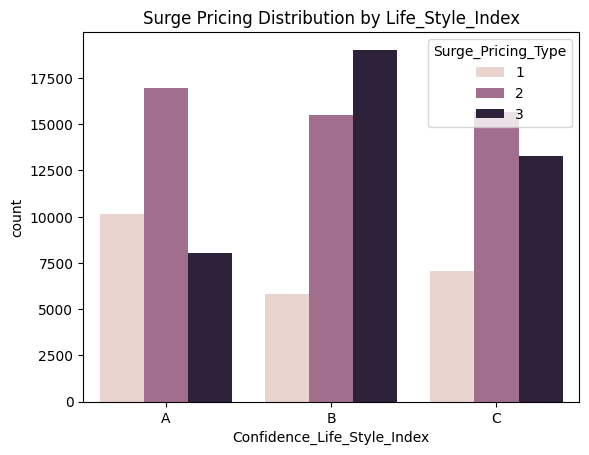

In [19]:
# See how Surge Pricing Type changes based on Life_Style_Index
sns.countplot(data=df, x='Confidence_Life_Style_Index', hue='Surge_Pricing_Type')
plt.title('Surge Pricing Distribution by Life_Style_Index')

Text(0.5, 1.0, 'Surge Pricing Distribution by Gender')

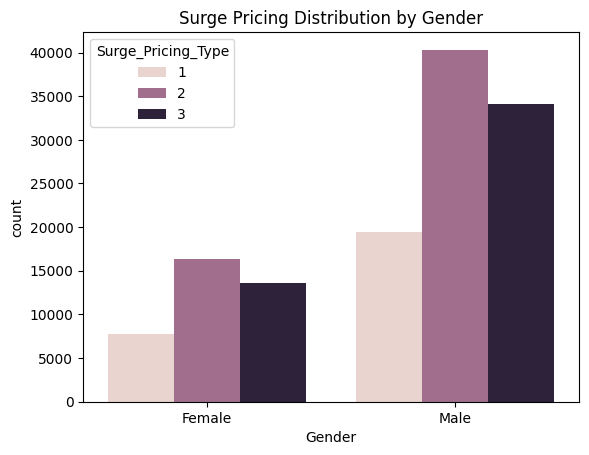

In [18]:
# See how Surge Pricing Type changes based on Gender
sns.countplot(data=df, x='Gender', hue='Surge_Pricing_Type')
plt.title('Surge Pricing Distribution by Gender')

Text(0.5, 1.0, 'Surge Pricing Distribution by Destination_Type')

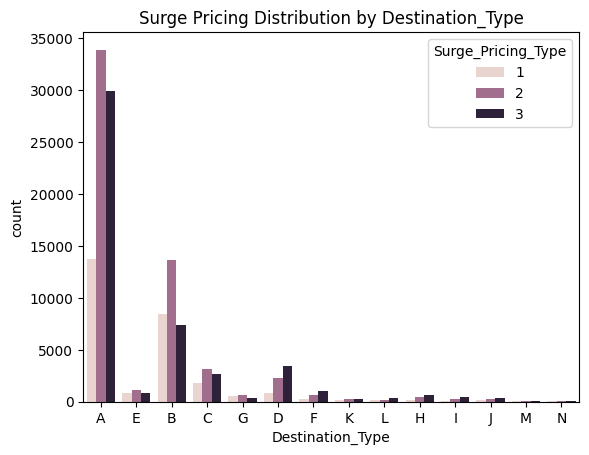

In [20]:
# See how Surge Pricing Type changes based on Destination_Type
sns.countplot(data=df, x='Destination_Type', hue='Surge_Pricing_Type')
plt.title('Surge Pricing Distribution by Destination_Type')

In [21]:
# 1. Fill Numerical with Median
df['Life_Style_Index'] = df['Life_Style_Index'].fillna(df['Life_Style_Index'].median())
df['Customer_Since_Months'] = df['Customer_Since_Months'].fillna(df['Customer_Since_Months'].median())

# 2. Fill Categorical with Mode (most frequent)
df['Type_of_Cab'] = df['Type_of_Cab'].fillna(df['Type_of_Cab'].mode()[0])
df['Confidence_Life_Style_Index'] = df['Confidence_Life_Style_Index'].fillna(df['Confidence_Life_Style_Index'].mode()[0])

# 3. Handle Var1 (The problematic one)
# Recommendation: Drop it since correlation is near 0 and >50% is missing
df.drop(columns=['Var1'], inplace=True)

In [22]:
df.isnull().sum()

Trip_Distance                  0
Type_of_Cab                    0
Customer_Since_Months          0
Life_Style_Index               0
Confidence_Life_Style_Index    0
Destination_Type               0
Customer_Rating                0
Cancellation_Last_1Month       0
Var2                           0
Var3                           0
Gender                         0
Surge_Pricing_Type             0
dtype: int64

<Axes: xlabel='Var3'>

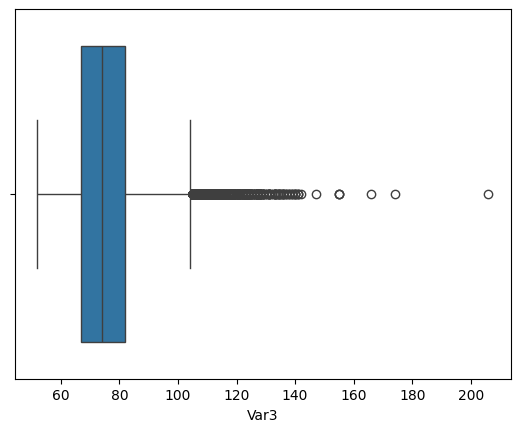

In [23]:
sns.boxplot(x=df['Var3'])

<Axes: xlabel='Var2'>

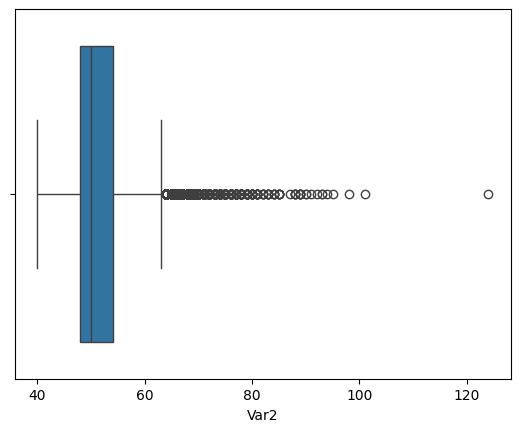

In [24]:
sns.boxplot(x=df['Var2'])